In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from shapely.geometry import Polygon
import pandas as pd

In [3]:
world = gpd.read_file('./data/shp/grid_vis.shp')

world = world.loc[world['region']=='Japan']

In [4]:
def add_colorbar(fig,ax,vmax,label,vmin=0,
                 cmap='autumn_r',
                 loc=[0.175,0.39,0.02,0.2],extend='max'):
        
    cax = ax.inset_axes(loc,transform=ax.transAxes)
    
    im = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=vmin,
                                                  vmax=vmax))
    
    if extend == 'none':
        cbar = fig.colorbar(im,cax=cax)
    else:
        cbar = fig.colorbar(im,cax=cax,extend=extend)
    
    cbar.outline.set_edgecolor('white')
    
    cbar.dividers.set_color('red')
    
    cbar.ax.tick_params(labelsize=15) 
    
    cbar.minorticks_on()
    
    cax.yaxis.tick_left()
    
    cbar.set_label(label,font={'size':15})
    


def draw_attr_map(fig,ax,geo,col,cmap,vmax,cbar_label,cbar_loc,draw_edge=False,extend='max'):
    
    world.plot(ax=ax,
               facecolor='whitesmoke',
               edgecolor='whitesmoke',
               lw=0.8)
    
    if draw_edge:
        geo.plot(ax=ax,
                column=col,
                cmap=cmap,
                vmax=vmax,
                edgecolor='silver',
                linewidth=0.25)
    else:
        geo.plot(ax=ax,
                column=col,
                cmap=cmap,
                vmax=vmax)
        
    world.boundary.plot(ax=ax,
                        edgecolor='silver',
                        lw=0.8)
        
    
    add_colorbar(fig=fig,
                 ax=ax,
                 label=cbar_label,
                 vmax=vmax,
                 cmap=cmap,
                 loc=cbar_loc,
                 extend=extend)

In [21]:
upv_res = pd.read_csv('./data/cap_sp/upv.csv')
dpv_res = pd.read_csv('./data/cap_sp/dpv.csv')
onshore_res = pd.read_csv('./data/cap_sp/onshore.csv')
offshore_res = pd.read_csv('./data/cap_sp/offshore.csv')

In [22]:
geo = []

for i,r in upv_res.iterrows():
    geo.append(Polygon([(r['lon'],r['lat']),
                        (r['lon']+0.25,r['lat']),
                        (r['lon']+0.25,r['lat']-0.25),
                        (r['lon'],r['lat']-0.25)]))
    
upv_res_gdf = gpd.GeoDataFrame(upv_res,geometry=geo,crs='epsg:4326')

geo = []

for i,r in dpv_res.iterrows():
    geo.append(Polygon([(r['lon'],r['lat']),
                        (r['lon']+0.25,r['lat']),
                        (r['lon']+0.25,r['lat']-0.25),
                        (r['lon'],r['lat']-0.25)]))
    
dpv_res_gdf = gpd.GeoDataFrame(dpv_res,geometry=geo,crs='epsg:4326')


geo = []

for i,r in onshore_res.iterrows():
    geo.append(Polygon([(r['lon'],r['lat']),
                        (r['lon']+0.25,r['lat']),
                        (r['lon']+0.25,r['lat']-0.25),
                        (r['lon'],r['lat']-0.25)]))
    
onshore_res_gdf = gpd.GeoDataFrame(onshore_res,geometry=geo,crs='epsg:4326')

geo = []

for i,r in offshore_res.iterrows():
    geo.append(Polygon([(r['lon'],r['lat']),
                        (r['lon']+0.25,r['lat']),
                        (r['lon']+0.25,r['lat']-0.25),
                        (r['lon'],r['lat']-0.25)]))
    
offshore_res_gdf = gpd.GeoDataFrame(offshore_res,geometry=geo,crs='epsg:4326')

we_res_gdf = pd.concat([onshore_res_gdf,offshore_res_gdf])

In [23]:
upv_res_gdf['capsp_dpv'] = 0.0

for i,r in upv_res_gdf.iterrows():
    try:
        capsp_dpv = dpv_res_gdf.loc[(dpv_res_gdf['lon']==r['lon'])&(dpv_res_gdf['lat']==r['lat']),'cap_sp']
        upv_res_gdf.at[i,'capsp_dpv'] = capsp_dpv
    except:
        pass

C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_26600\1494254016.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  upv_res_gdf.at[i,'capsp_dpv'] = capsp_dpv


In [24]:
def get_capsp_quant(sp):
    if sp < 3:
        return 0
    elif sp < 6:
        return 1
    elif sp < 9:
        return 2
    elif sp < 12:
        return 3
    else:
        return 4

In [25]:
upv_res_gdf['y_class'] = 0
upv_res_gdf['x_class'] = 0

for i,r in upv_res_gdf.iterrows():
    upv_res_gdf.at[i,'x_class'] = get_capsp_quant(r['cap_sp'])
    upv_res_gdf.at[i,'y_class'] = get_capsp_quant(r['capsp_dpv'])

In [26]:
bivar_colors = {
    "00": "#ffffff", "01": "#dbe9f6", "02": "#b7d5f0", "03": "#92c1e9", "04": "#6eaddf",
    "10": "#f6dbdb", "11": "#dbcfcf", "12": "#b7c3d0", "13": "#92b7cd", "14": "#6eabc8",
    "20": "#f0b7b7", "21": "#d0b0b0", "22": "#a0a0c0", "23": "#8080c0", "24": "#6060c0",
    "30": "#e99292", "31": "#cd9292", "32": "#a092b7", "33": "#8080b7", "34": "#6060b7",
    "40": "#df6e6e", "41": "#c86e6e", "42": "#b76ea0", "43": "#9255a8", "44": "#7040a0",
}

In [27]:
upv_res_gdf["bivar_class"] = upv_res_gdf["y_class"].astype(str) + upv_res_gdf["x_class"].astype(str)

upv_res_gdf["color"] = upv_res_gdf["bivar_class"].map(bivar_colors)

In [28]:
import matplotlib.patches as mpatches

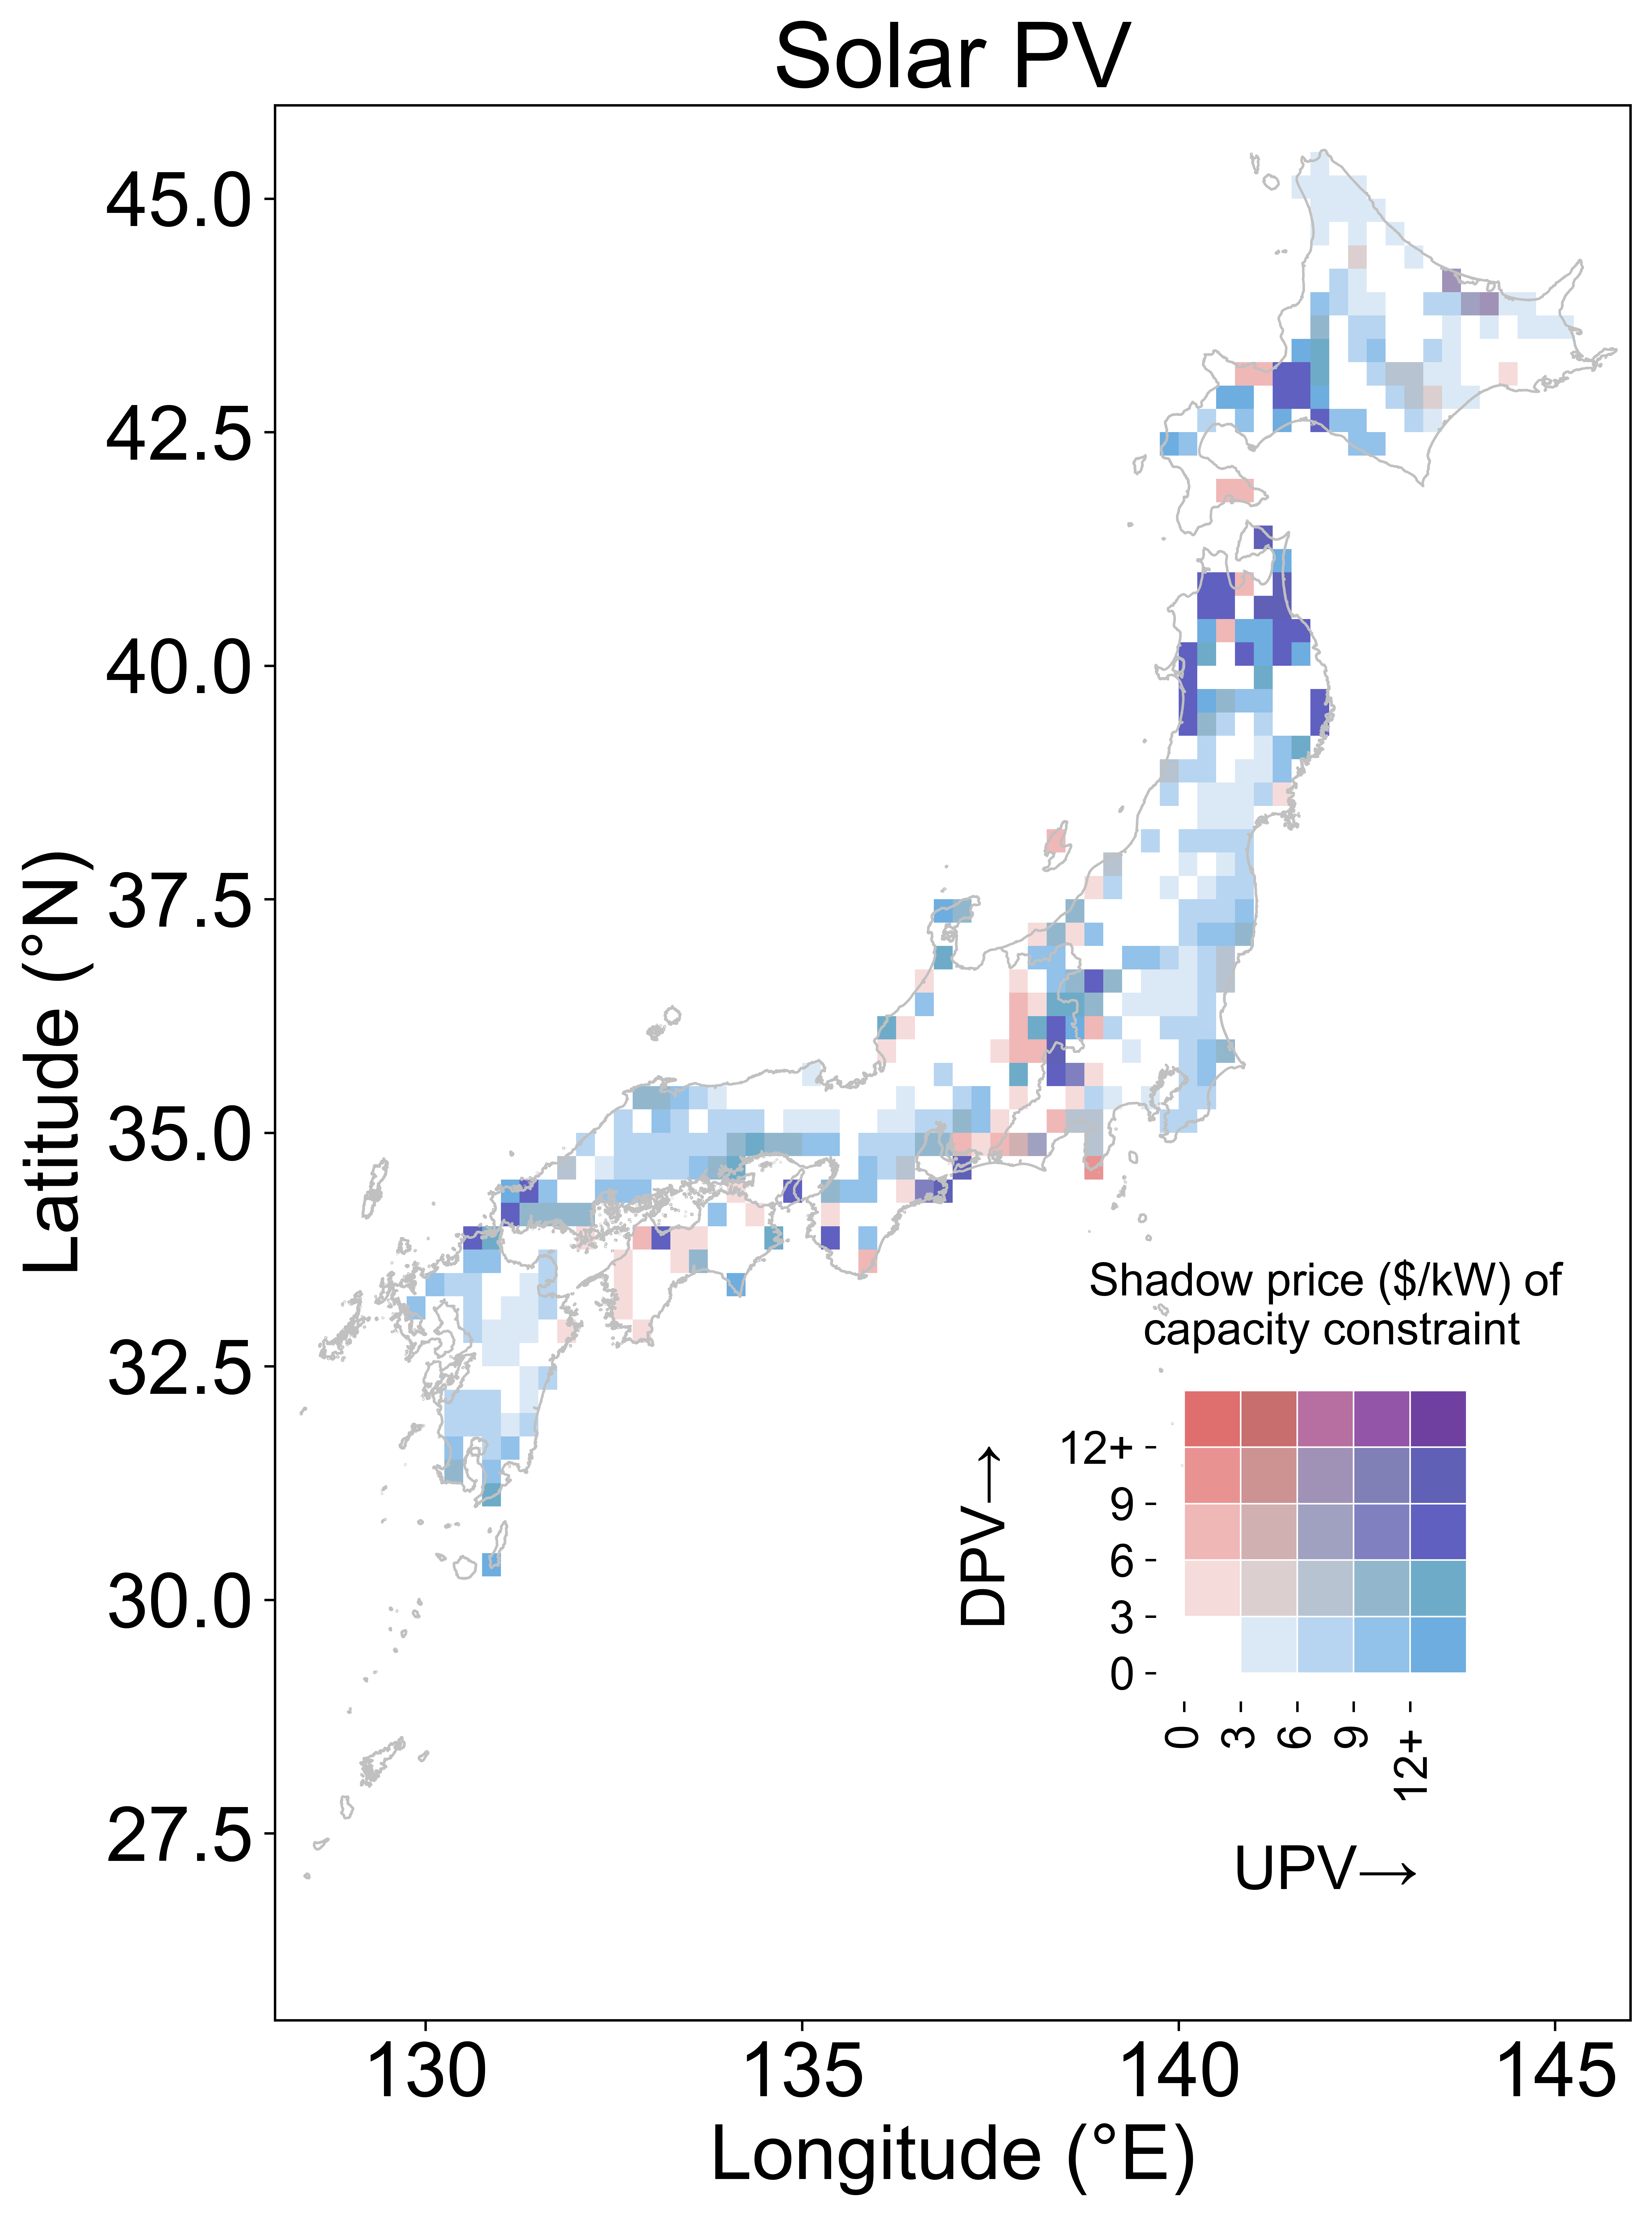

In [29]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 25

# 创建主地图
fig, ax = plt.subplots(1, 1, figsize=(8, 12),dpi=800)

ax.set_facecolor("white")  # 设置背景为白色，防止不美观


upv_res_gdf.plot(color=upv_res_gdf['color'],
                 edgecolor="none", 
                 linewidth=0.25, 
                 ax=ax)

world.boundary.plot(ax=ax,
                    edgecolor='silver',
                    lw=0.8)

# **在主图上添加图例**
legend_ax = ax.inset_axes((0.65, 0.13, 0.25, 0.25)) # X,Y,Widt,Height

# **绘制 5x5 颜色矩阵**
for i in range(5):
    for j in range(5):
        color = bivar_colors[f"{i}{j}"]
        rect = mpatches.Rectangle((j, i), 1, 1, color=color, ec="white", lw=0.5)
        legend_ax.add_patch(rect)

# **设置 X 轴 (pv_profit Percentiles)**
legend_ax.set_xticks([0, 1, 2, 3, 4])
legend_ax.set_xticklabels(["0", "3", "6", "9", "12+"], fontsize=15)
legend_ax.set_xlabel("UPV→", fontsize=20, labelpad=15)
# **调整 X 轴标签角度**
for label in legend_ax.get_xticklabels():
    label.set_rotation(90)
    label.set_horizontalalignment("center")

# **设置 Y 轴 (we_profit Percentiles)**
legend_ax.set_yticks([0, 1, 2, 3, 4])
legend_ax.set_yticklabels(["0", "3", "6", "9", "12+"], fontsize=15)
legend_ax.set_ylabel("DPV→", fontsize=20, labelpad=15)

# **确保图例完整显示**
legend_ax.set_xlim(-0.5, 5.5)
legend_ax.set_ylim(-0.5, 5.5)
legend_ax.set_aspect('equal')  # **确保矩阵保持正方形**
legend_ax.set_frame_on(False)

legend_ax.set_title("Shadow price ($/kW) of\n capacity constraint",fontsize=15)

ax.set_xlim(128,146)
ax.set_ylim(25.5,46)


ax.set_title('Solar PV')

ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.savefig('./fig/pv_capsp_japan.jpg',bbox_inches='tight')

plt.show()

In [30]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 25


fig,ax = plt.subplots(figsize=(8,12),dpi=800)


draw_attr_map(fig=fig,
              ax=ax,
              geo=we_res_gdf,
              col='cap_sp',
              cmap='gist_earth_r',
              cbar_label='Shadow price ($/kW) of\n capacity constraint',
              vmax=200,
              cbar_loc=[0.8,0.2,0.04,0.25],
              extend='max')

ax.set_xlim(128,146)
ax.set_ylim(25.5,46)

#ax.axis('off')

ax.set_title('Wind power')

#ax.set_xticks([],[])
#ax.set_yticks([],[])
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.savefig('./fig/we_cap_sp_jpan.jpg',bbox_inches='tight')
plt.savefig('./fig/we_cap_sp_jpan.pdf',bbox_inches='tight')

plt.close()